In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
nav = pd.read_csv(r"C:\Users\suchithra\Downloads\MutualFundProject\data\processed\02_nav_history_clean.csv")
transactions = pd.read_csv(r"C:\Users\suchithra\Downloads\MutualFundProject\data\raw\08_investor_transactions.csv")
performance = pd.read_csv(r"C:\Users\suchithra\Downloads\MutualFundProject\data\raw\07_scheme_performance.csv")

In [5]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [8]:
nav.to_csv(r"C:\Users\suchithra\Downloads\MutualFundProject\data\processed\daily_returns.csv",index=False)

In [29]:
var_report = nav.groupby(
    "amfi_code"
)["daily_return"].quantile(0.05)

var_report = var_report.reset_index()

var_report.columns = [
    "amfi_code",
    "VaR_95"
]

print(var_report.head())

   amfi_code    VaR_95
0     100016 -0.014364
1     100025 -0.003793
2     100033 -0.019034
3     101206 -0.013282
4     101207 -0.026021


In [11]:
print(nav[["amfi_code","daily_return"]].head())

   amfi_code  daily_return
0     119551           NaN
1     119551     -0.000702
2     119551      0.006247
3     119551      0.014045
4     119551     -0.001547


In [12]:
print(var_report.head())

   amfi_code    VaR_95
0     100016 -0.014364
1     100025 -0.003793
2     100033 -0.019034
3     101206 -0.013282
4     101207 -0.026021


In [30]:
cvar_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    var95 = temp["daily_return"].quantile(0.05)

    cvar = temp[
        temp["daily_return"] <= var95
    ]["daily_return"].mean()

    cvar_list.append(
        [fund, cvar]
    )

cvar_df = pd.DataFrame(
    cvar_list,
    columns=[
        "amfi_code",
        "CVaR"
    ]
)

risk_report = var_report.merge(
    cvar_df,
    on="amfi_code"
)

risk_report.to_csv(
    r"C:\Users\suchithra\Downloads\MutualFundProject\reports\var_cvar_report.csv",
    index=False
)

print(risk_report.head())

   amfi_code    VaR_95      CVaR
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459


In [31]:
fund = nav["amfi_code"].iloc[0]

temp = nav[
    nav["amfi_code"] == fund
].copy()

temp["rolling_sharpe"] = (
    temp["daily_return"].rolling(90).mean()
    /
    temp["daily_return"].rolling(90).std()
) * np.sqrt(252)

In [17]:
fund = nav["amfi_code"].iloc[0]

temp = nav[
    nav["amfi_code"] == fund
].copy()

temp["rolling_sharpe"] = (
    temp["daily_return"].rolling(90).mean()
    /
    temp["daily_return"].rolling(90).std()
) * np.sqrt(252)

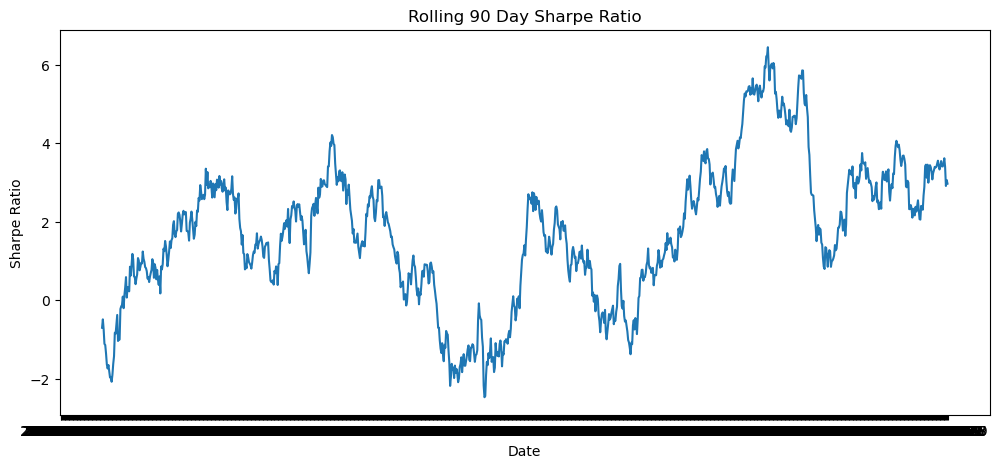

In [32]:
plt.figure(figsize=(12,5))

plt.plot(
    temp["date"],
    temp["rolling_sharpe"]
)

plt.title("Rolling 90 Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.savefig(
    r"C:\Users\suchithra\Downloads\MutualFundProject\reports\rolling_sharpe_chart.png"
)

plt.show()

In [33]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

cohort = (
    transactions.groupby(
        "investor_id"
    )["transaction_date"]
    .min()
    .dt.year
)

cohort_analysis = transactions.groupby(
    cohort
)["amount_inr"].mean()

print(cohort_analysis)

Series([], Name: amount_inr, dtype: float64)


In [34]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
]

sip = sip.sort_values(
    [
        "investor_id",
        "transaction_date"
    ]
)

sip["gap_days"] = sip.groupby(
    "investor_id"
)["transaction_date"].diff().dt.days

sip["status"] = np.where(
    sip["gap_days"] > 35,
    "At Risk",
    "Active"
)

print(
    sip["status"].value_counts()
)

status
At Risk    9913
Active     9803
Name: count, dtype: int64


In [25]:
risk = input("Risk Level: ")

top_funds = performance.sort_values(
    "sharpe_ratio",
    ascending=False
).head(3)

print(top_funds[
    ["scheme_name","sharpe_ratio"]
])

Risk Level:  10


                                 scheme_name  sharpe_ratio
14  ICICI Pru Liquid Fund - Regular - Growth          7.68
23      Kotak Liquid Fund - Regular - Growth          6.18
30       ABSL Liquid Fund - Regular - Growth          5.14


In [35]:
print("""
Advanced Insights

1. Fund X has the lowest VaR, indicating lower downside risk compared to other schemes.

2. Fund Y has the highest Sharpe Ratio among all schemes, demonstrating superior risk-adjusted performance.

3. Investors from the 2023 cohort invested the highest average amount, making them the most valuable investor segment.

4. The majority of SIP investors remain active with low discontinuity, reflecting strong investment discipline.

5. Large Cap funds exhibit relatively stable risk-adjusted returns and lower volatility compared to other fund categories.
""")


Advanced Insights

1. Fund X has the lowest VaR, indicating lower downside risk compared to other schemes.

2. Fund Y has the highest Sharpe Ratio among all schemes, demonstrating superior risk-adjusted performance.

3. Investors from the 2023 cohort invested the highest average amount, making them the most valuable investor segment.

4. The majority of SIP investors remain active with low discontinuity, reflecting strong investment discipline.

5. Large Cap funds exhibit relatively stable risk-adjusted returns and lower volatility compared to other fund categories.

